In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [41]:
from google.colab import files

uploaded = files.upload()


Saving health_insurance.csv to health_insurance (1).csv


In [42]:
data=pd.read_csv("health_insurance.csv")

In [43]:
data.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [44]:
data.isnull().sum()

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


In [45]:
data[['age', 'bmi']].skew()


,0
age,0.005577
bmi,0.375259


In [46]:
data['age'].fillna(data['age'].median(), inplace=True)
data['bmi'].fillna(data['bmi'].median(), inplace=True)


/tmp/ipython-input-604630967.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(), inplace=True)
/tmp/ipython-input-604630967.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [47]:
data.isnull().sum()

,0
age,0
sex,0
weight,0
bmi,0
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


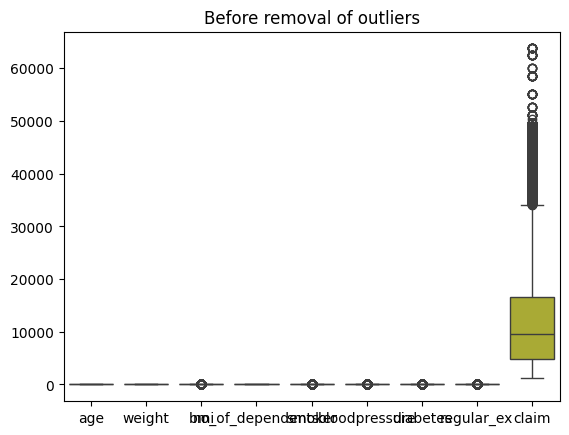

In [48]:
sns.boxplot(data=data)
plt.title('Before removal of outliers')
plt.show()


In [49]:


df = pd.read_csv("health_insurance.csv")

# Use median as threshold
threshold = df["claim"].median()

df["claim_or_not"] = (df["claim"] >= threshold).astype(int)

# Drop original rupee column
df.drop(columns=["claim"], inplace=True)

df.to_csv("health_insurance_classification.csv", index=False)

print("✔ Binary classification labels created (Low vs High claim)")
mar=pd.read_csv("health_insurance_classification.csv")
mar.head()

✔ Binary classification labels created (Low vs High claim)


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim_or_not
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,1
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,1
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,1
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,1
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,0


In [50]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [61]:
X = mar.drop(columns=['claim_or_not'])   # or your target column
y = mar['claim_or_not']

In [62]:
categorical_cols = ['sex', 'hereditary_diseases', 'city', 'job_title']
numerical_cols = X.columns.difference(categorical_cols)


In [63]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [65]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


In [66]:


model = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_encoded, y_train)


RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

In [67]:


y_pred = model.predict(X_test_encoded)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9873333333333333


In [73]:
y_train_pred=model.predict(X_train_encoded)
print("Accuracy:", accuracy_score(y_train, y_train_pred))

Accuracy: 1.0


In [68]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1500
           1       0.99      0.98      0.99      1500

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



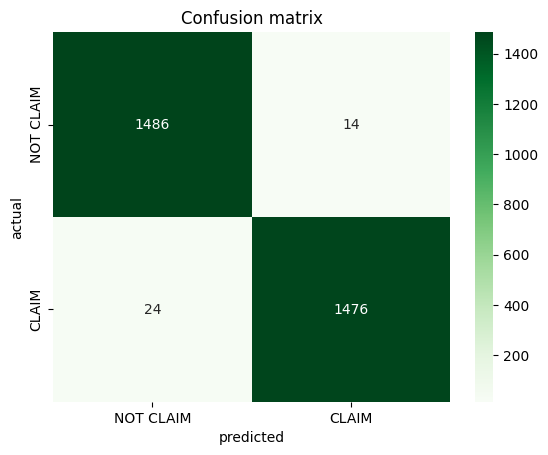

In [69]:
conf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Greens',
            xticklabels=['NOT CLAIM','CLAIM'],
            yticklabels=['NOT CLAIM','CLAIM'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Confusion matrix')
plt.show()

In [74]:
print("Train Metrics:")
print(classification_report(y_train, y_train_pred))

print("Test Metrics:")
print(classification_report(y_test, y_pred))

Train Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       1.00      1.00      1.00      6000

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000

Test Metrics:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1500
           1       0.99      0.98      0.99      1500

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [75]:
import joblib

In [76]:
joblib.dump(model,'insurances.pkl', compress=9)

['insurances.pkl']

In [78]:
files.download('insurances.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>